In [6]:
from sklearn.metrics import *
import numpy as np

np.set_printoptions(suppress=True)
pd.options.display.float_format = '{:,.2f}'.format

In [7]:
import pandas as pd
from ESRNN import ESRNN
from ESRNN.utils_evaluation import evaluate_prediction_owa
from ESRNN.utils_visualization import plot_grid_prediction




# Load your time series data
# Ensure your dataframe has 'unique_id', 'ds' (date), and 'y' (value) columns
df = pd.read_excel('../preprocessedBelgeler/mapped_ES_RNN Adjusted.xlsx')
df['unique_id'] = df['unique_id'].astype(str)
old_df = df
"""
# Her unique_id için y=0 olan satırların sayısını hesapla
zero_counts = df[df['y'] == 0].groupby('unique_id').size()

# y=0 sayısı 24'ten büyük olan unique_id'leri bul
ids_with_many_zeros = zero_counts[zero_counts > 24].index

# Bu id'lere sahip tüm verileri çıkararak filtrele
df = df[~df['unique_id'].isin(ids_with_many_zeros)]
"""




# Remove rows where y is zero
df['y'] = df['y'].replace(0, 0.01)

zero_mask = df['y'] == 0
num_zeros = zero_mask.sum()


df = df.sort_values(by=["unique_id", "ds"])

#df['y'] = 50*df['y']

# Split data into training and testing sets

#train_df = df[(df['ds'] >= '2020-01-01') & (df['ds'] <= '2023-12-31')]
train_df = df[(df['ds'] >= '2022-01-01') & (df['ds'] <= '2024-05-31')]
test_df = df[(df['ds'] >= '2024-06-01') & (df['ds'] <= '2024-12-31')]

#X_train_df = train_df[X_columns].reset_index(drop=True)
#y_train_df = train_df[y_column].reset_index(drop=True)


# Define Features (X) and Target (y)
X_columns = ["unique_id","ds", "x"]  # Features
y_column = [ "unique_id","ds","y"]  # Target variable


model = ESRNN(
    max_epochs=20,
    freq_of_test=1,
    batch_size=4,
    learning_rate=0.001, per_series_lr_multip=1.0,
    lr_scheduler_step_size=10, lr_decay=0.5,
    gradient_clipping_threshold=5,
    rnn_weight_decay=0.0, noise_std=0.001,
    level_variability_penalty=0,        # << yumuşatma etkisini sıfırla
    testing_percentile=10, training_percentile=50,
    ensemble=True, max_periods=70,
    seasonality=[12],                 
    input_size=12,                      # << daha geniş geçmiş
    output_size=7,                      # << daha kısa ileri tahmin
    cell_type='LSTM',
    state_hsize=40,                     # << öğrenme kapasitesi artır
    add_nl_layer=False,
    random_seed=1, device='cpu'
)






# Split into X and y for training and testing
X_train_df = train_df[X_columns].reset_index(drop=True)
y_train_df = train_df[y_column].reset_index(drop=True)

print(y_train_df)
X_test_df = test_df[X_columns]
y_test_df = test_df[y_column]


"""
X_train_df = train_df[X_columns].reset_index(drop=True)
y_train_df = train_df[y_column].reset_index(drop=True)
"""


# Fit the model
model.fit(X_train_df, y_train_df)





print(X_test_df)
y_hat = model.predict(X_test_df)
print(y_hat)


      unique_id         ds      y
0             1 2022-01-01  40.00
1             1 2022-02-01 219.34
2             1 2022-03-01 100.00
3             1 2022-04-01 280.00
4             1 2022-05-01 124.00
...         ...        ...    ...
38362       999 2024-01-01   0.01
38363       999 2024-02-01   0.01
38364       999 2024-03-01   0.01
38365       999 2024-04-01   0.01
38366       999 2024-05-01   0.01

[38367 rows x 3 columns]
Infered frequency: MS
=============== Training ESRNN  ===============

========= Epoch 0 finished =========
Training time: 2.43343
Training loss (50 prc): 0.80538
========= Epoch 1 finished =========
Training time: 2.46155
Training loss (50 prc): 0.64484
========= Epoch 2 finished =========
Training time: 2.41967
Training loss (50 prc): 0.61759
========= Epoch 3 finished =========
Training time: 2.416
Training loss (50 prc): 0.59241
========= Epoch 4 finished =========
Training time: 2.41652
Training loss (50 prc): 0.57803
========= Epoch 5 finished =========


In [8]:
comparison_df = y_hat.merge(y_test_df, on=['unique_id', 'ds'], how='left')
print(comparison_df)
def save_datasets(comparison_df, folder_path="/Users/cankocak/Desktop/Spring25/"):
    
    
    import os
    os.makedirs(folder_path, exist_ok=True)  # Ensure directory exists

    # Save DataFrames
    #comparison_df.to_csv(f"{folder_path}comparison_df.csv", index=False)

    #print(f"Data saved in '{folder_path}' before running the model.")

# Save Data Before Running the Model
#save_datasets(comparison_df)

print(y_hat)

     unique_id         ds       x  y_hat     y
0            1 2024-06-01       A  61.88 43.00
1            1 2024-07-01       A  46.03  0.01
2            1 2024-08-01       A  22.64 63.00
3            1 2024-09-01       A  80.60  0.01
4            1 2024-10-01       A  13.79 40.00
...        ...        ...     ...    ...   ...
9256       999 2024-08-01  DD11-1   0.01  0.01
9257       999 2024-09-01  DD11-1   0.01  0.01
9258       999 2024-10-01  DD11-1   0.01  0.01
9259       999 2024-11-01  DD11-1   0.01  0.01
9260       999 2024-12-01  DD11-1   0.01  0.01

[9261 rows x 5 columns]
     unique_id         ds       x  y_hat
0            1 2024-06-01       A  61.88
1            1 2024-07-01       A  46.03
2            1 2024-08-01       A  22.64
3            1 2024-09-01       A  80.60
4            1 2024-10-01       A  13.79
...        ...        ...     ...    ...
9256       999 2024-08-01  DD11-1   0.01
9257       999 2024-09-01  DD11-1   0.01
9258       999 2024-10-01  DD11-1   0.01
9

In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import numpy as np

# Önce gerçek verileri filtrele
filtered_true = y_test_df[y_test_df['y'] > -0.01][['unique_id', 'ds', 'y']]

# Tahmin edilen verileri al
pred_df = y_hat[['unique_id', 'ds', 'y_hat']]

# Hem unique_id hem de Month'a göre eşleşen verileri merge ile bul
merged_df = pd.merge(filtered_true, pred_df, on=['unique_id', 'ds'], how='inner')

# Elde edilen eşleşmiş değerlerle metrikleri hesapla
y_true = merged_df['y']
y_pred = merged_df['y_hat']

mae_filtered = mean_absolute_error(y_true, y_pred)
mape_filtered = mean_absolute_percentage_error(y_true, y_pred) * 100
rmse_filtered = np.sqrt(mean_squared_error(y_true, y_pred))
smape_filtered = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
wmape_filtered = 100 * np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true))

# Sonuçları yazdır
print(f"Eşleşen satır sayısı: {len(merged_df)}")
print(f"📉 Filtrelenmiş MAE   : {mae_filtered:.4f}")
print(f"📊 Filtrelenmiş MAPE  : {mape_filtered:.2f}%")
print(f"📐 Filtrelenmiş RMSE  : {rmse_filtered:.4f}")
print(f"🔁 Filtrelenmiş sMAPE : {smape_filtered:.2f}%")
print(f"⚖️  Filtrelenmiş wMAPE : {wmape_filtered:.2f}%")

# Sonucu Excel'e kaydetmek istersen
#merged_df.to_excel("matched_y_true_vs_y_hat.xlsx", index=False)




Eşleşen satır sayısı: 9261
📉 Filtrelenmiş MAE   : 26.7867
📊 Filtrelenmiş MAPE  : 9183.74%
📐 Filtrelenmiş RMSE  : 141.4063
🔁 Filtrelenmiş sMAPE : 64.90%
⚖️  Filtrelenmiş wMAPE : 64.35%


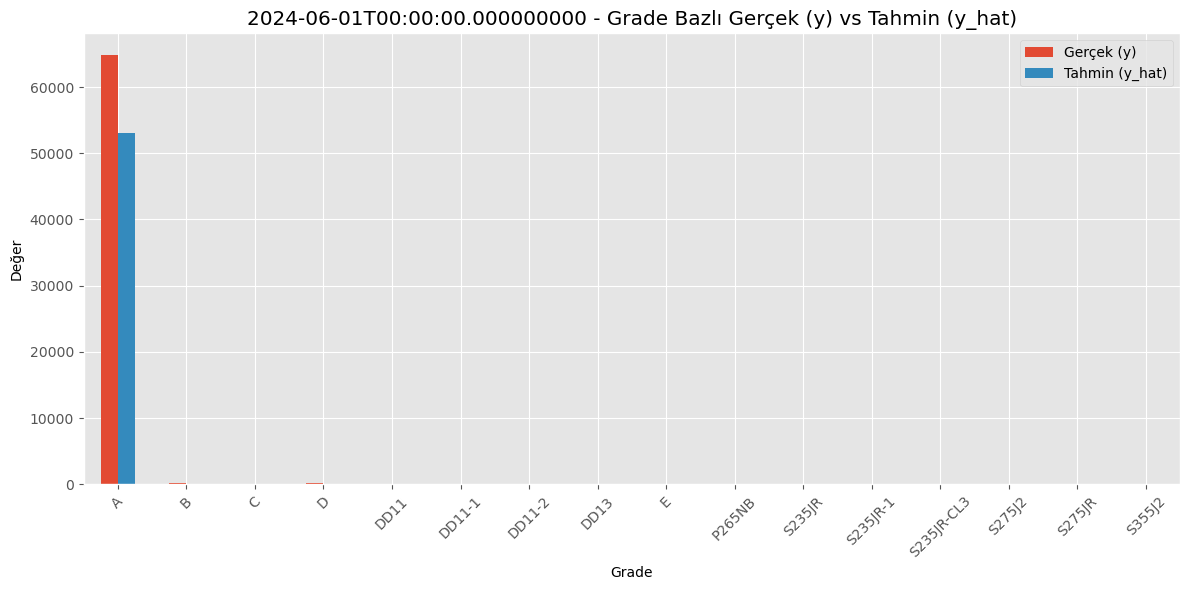

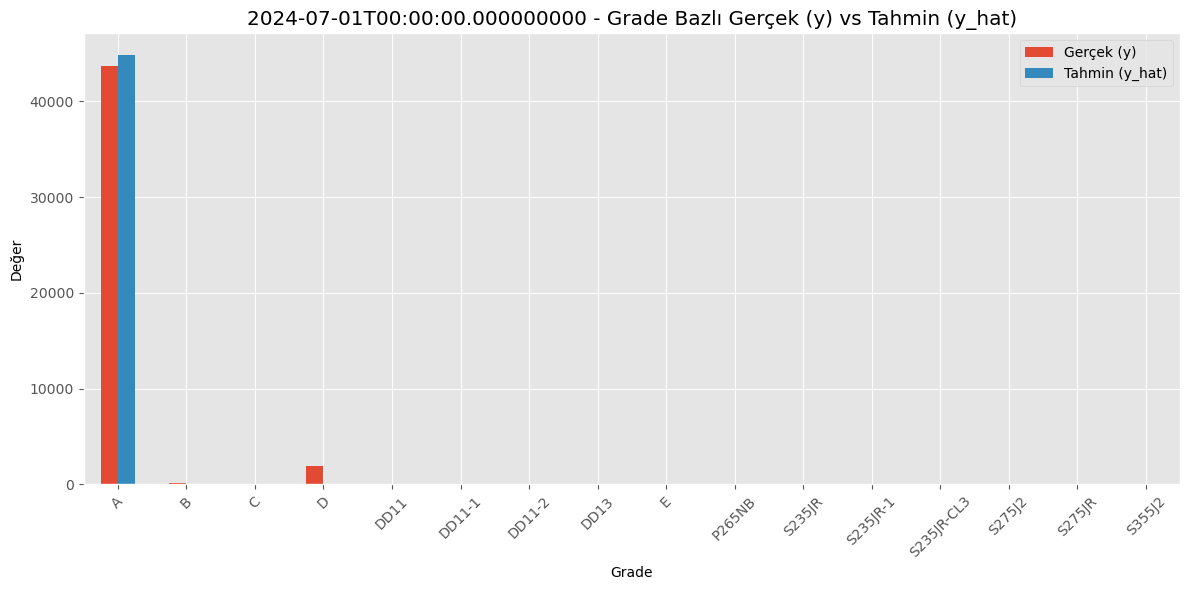

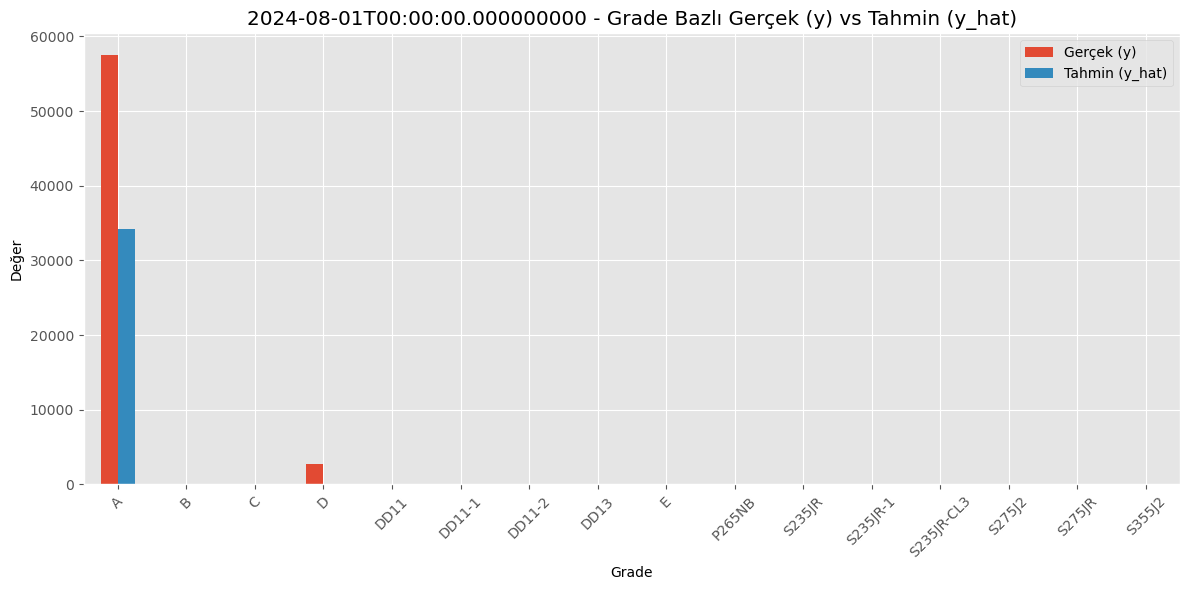

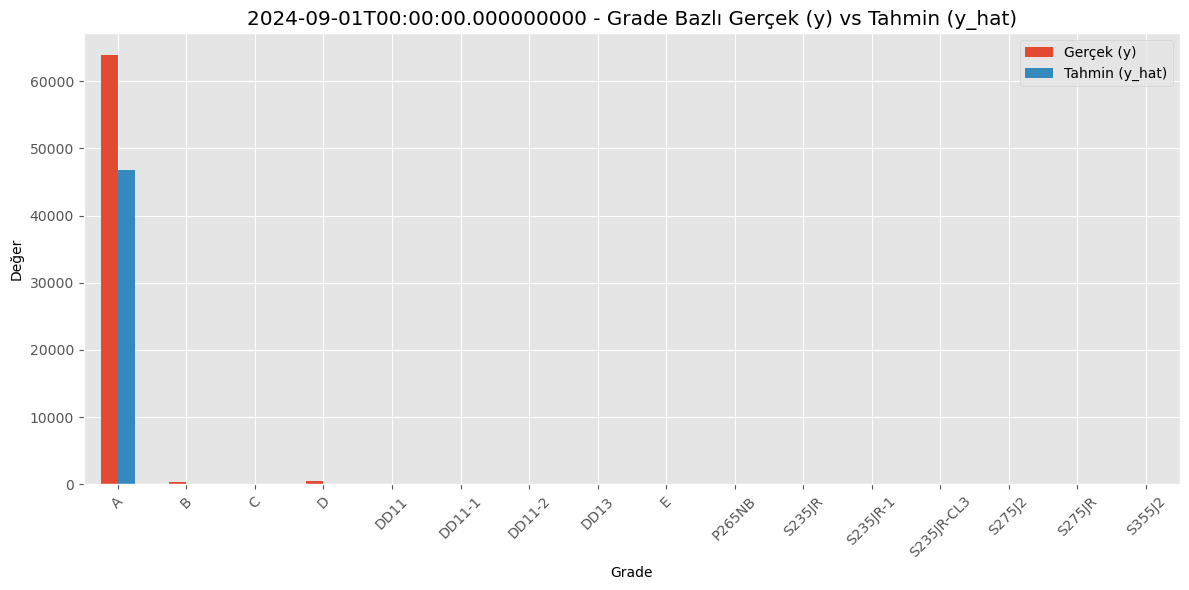

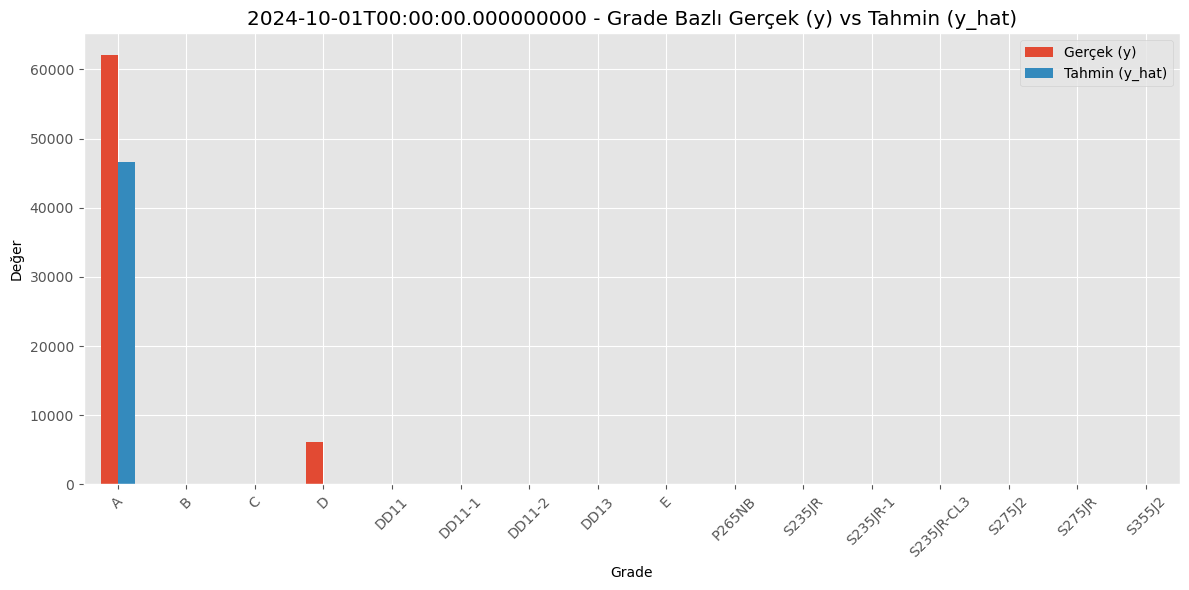

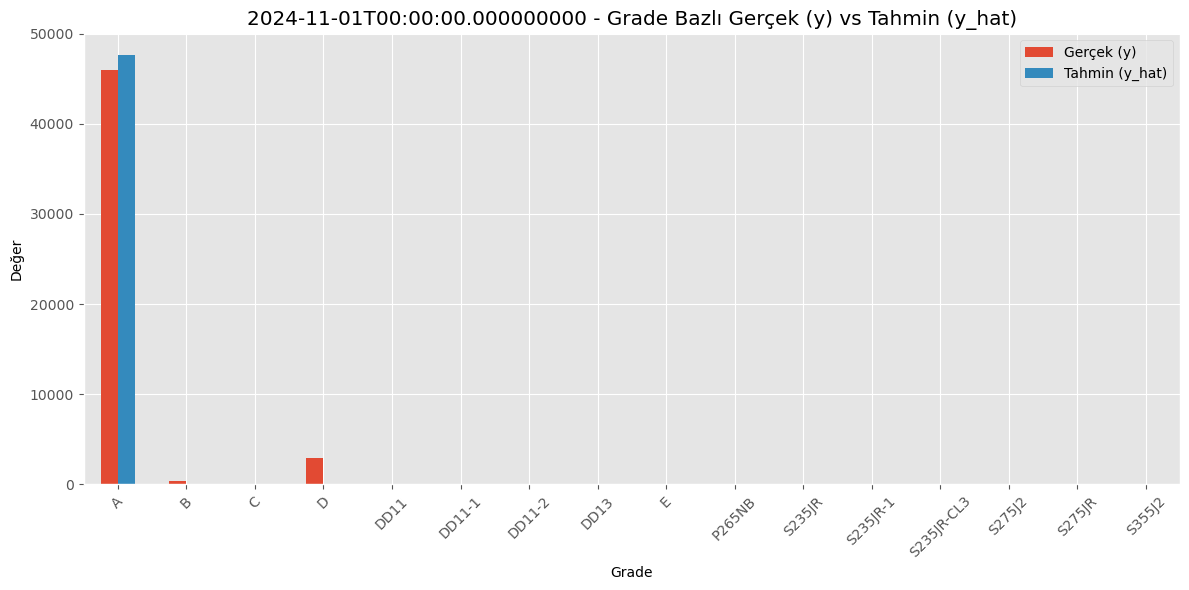

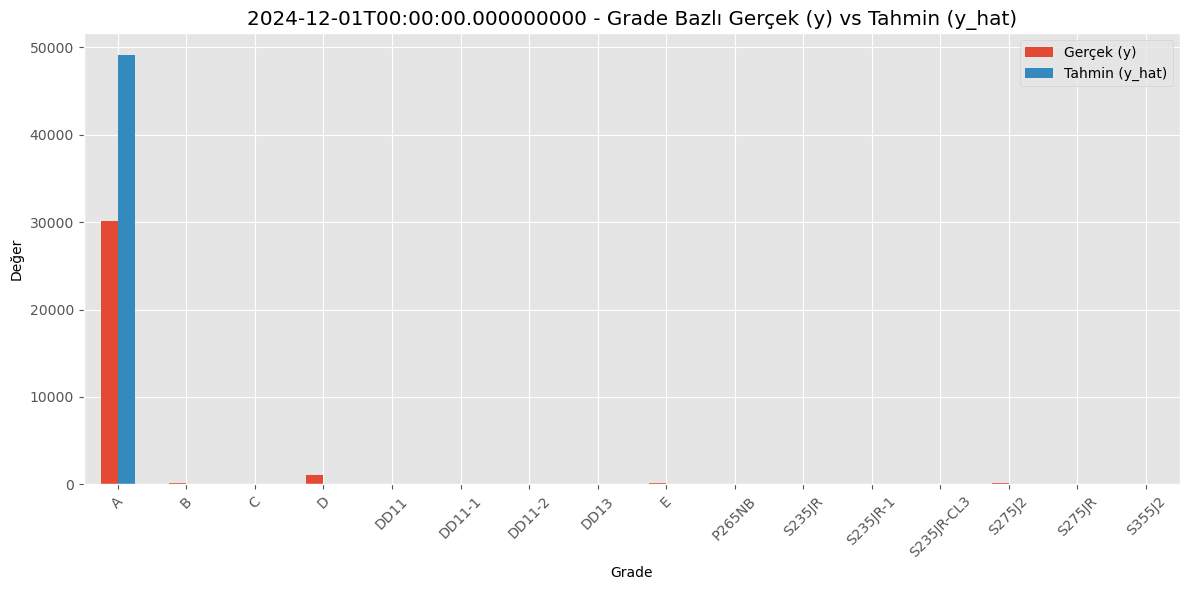

In [10]:

# unique_id ve ds'e göre left join
merged_df = pd.merge(y_test_df, y_hat, on=['unique_id', 'ds'], how='left')
mergeeee = merged_df
aggregated_df_y_hat = merged_df.groupby(['ds', 'x'])['y_hat'].sum().reset_index()

aggregated_df_y = merged_df.groupby(['ds', 'x'])['y'].sum().reset_index()

import pandas as pd
import matplotlib.pyplot as plt

# Ortaklaştır
merged_df = pd.merge(aggregated_df_y, aggregated_df_y_hat, on=['ds', 'x'], how='inner')

# Her ay (ds) için ayrı grafik çiz
for ds_value in merged_df['ds'].unique():
    subset = merged_df[merged_df['ds'] == ds_value].set_index('x')
    
    subset[['y', 'y_hat']].plot(kind='bar', figsize=(12, 6))
    plt.title(f"{ds_value} - Grade Bazlı Gerçek (y) vs Tahmin (y_hat)")
    plt.ylabel("Değer")
    plt.xlabel("Grade")
    plt.xticks(rotation=45)
    plt.legend(["Gerçek (y)", "Tahmin (y_hat)"])
    plt.tight_layout()
    plt.show()



In [11]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

# 🔹 1. Grade + Ay (ds + x) bazında toplam
grade_monthly = mergeeee.groupby(['ds', 'x']).agg({'y': 'sum', 'y_hat': 'sum'}).reset_index()

# 🔹 2. Tüm Grade + Ay bazlı değerleri düz liste haline getir
y_true = grade_monthly['y'].values
y_pred = grade_monthly['y_hat'].values

# 🔹 3. Error metric hesaplamaları
mae = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred) * 100
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
wmape = 100 * np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true))

# 🔥 Sonucu yazdıralım
print(f"\n📦 (Grade + Ay Bazlı) Toplam Performans:")
print(f"MAE   : {mae:.4f}")
print(f"MAPE  : {mape:.2f}%")
print(f"sMAPE : {smape:.2f}%")
print(f"wMAPE : {wmape:.2f}%")
print(f"RMSE  : {rmse:.4f}")





📦 (Grade + Ay Bazlı) Toplam Performans:
MAE   : 955.6384
MAPE  : 59.57%
sMAPE : 70.50%
wMAPE : 27.76%
RMSE  : 3834.9886


In [12]:
# Filtreleme koşulu
filtered_indices = y_test_df['y'] > 0.1

# Yalnızca koşula uyan gerçek değerleri seç
filtered_y_true = y_test_df.loc[filtered_indices, 'y']

# Ortak indexlerde kesişim yaparak tahmin değerlerini seç
common_indices = filtered_y_true.index.intersection(y_hat.index)

# Ortak indexler ile filtrelenmiş değerler
filtered_y_true = y_test_df.loc[common_indices, 'y']
filtered_y_pred = y_hat.loc[common_indices, 'y_hat']
filtered_unique_ids = y_test_df.loc[common_indices, 'unique_id']

# Sonuçları içeren DataFrame oluştur
filtered_results_df = pd.DataFrame({
    'unique_id': filtered_unique_ids,
    'y_true': filtered_y_true,
    'y_predicted': filtered_y_pred
})

# Excel dosyasına kaydet
#filtered_results_df.to_excel('filtered_true_vs_predicted_with_id.xlsx', index=False)


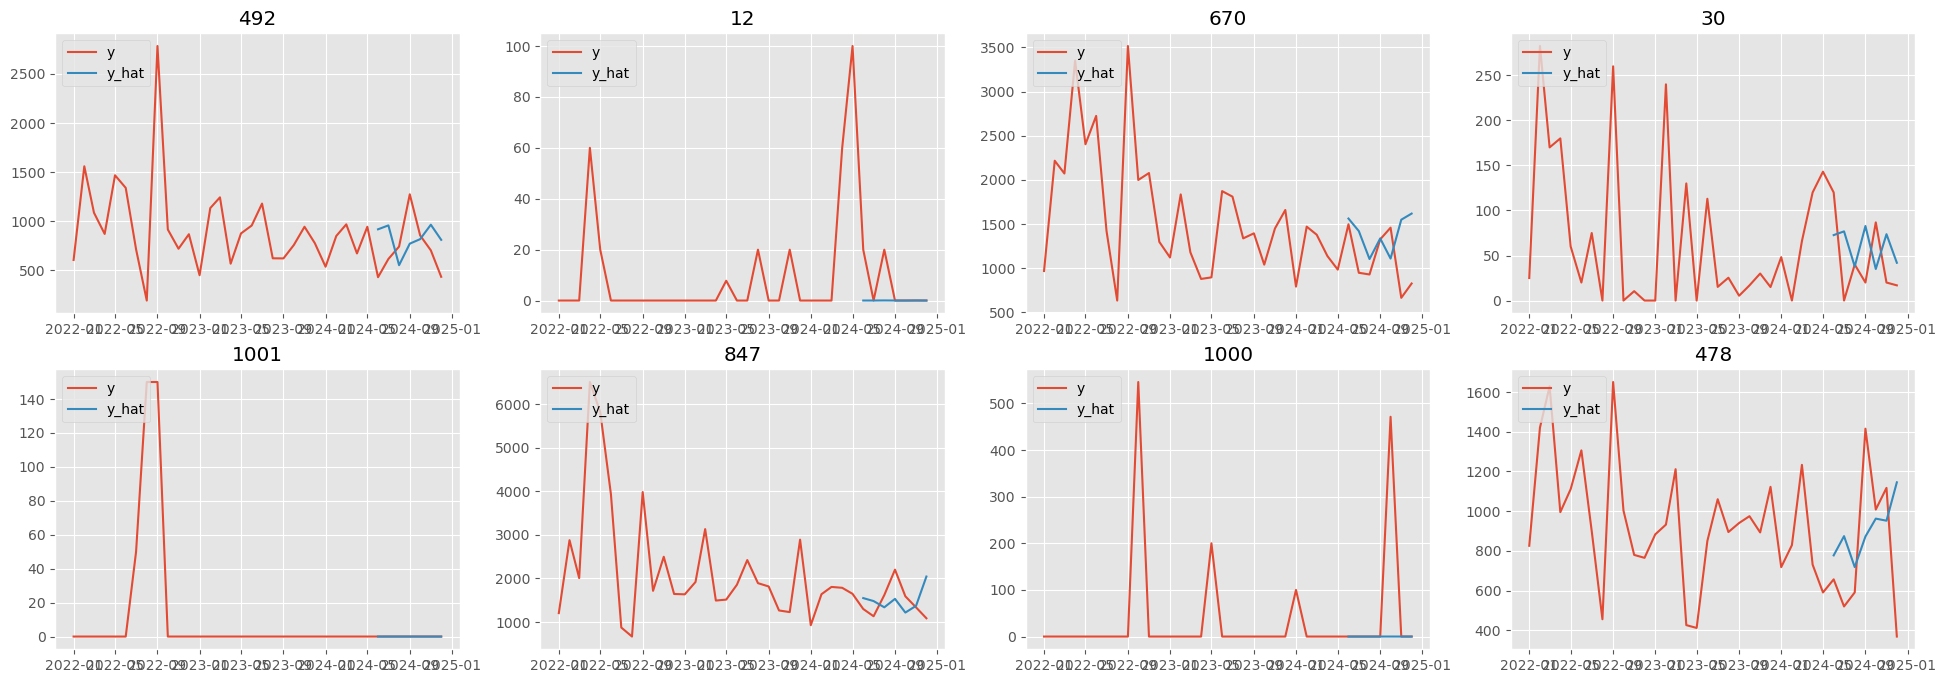

In [13]:
unique_ids = ['670', '847','478','492','12','30','1000','1001']

plot_preds = pd.concat([y_train_df.groupby('unique_id').tail(50), 
                        y_test_df],  sort=True)

plot_grid_prediction(plot_preds, y_hat,  unique_ids=unique_ids)

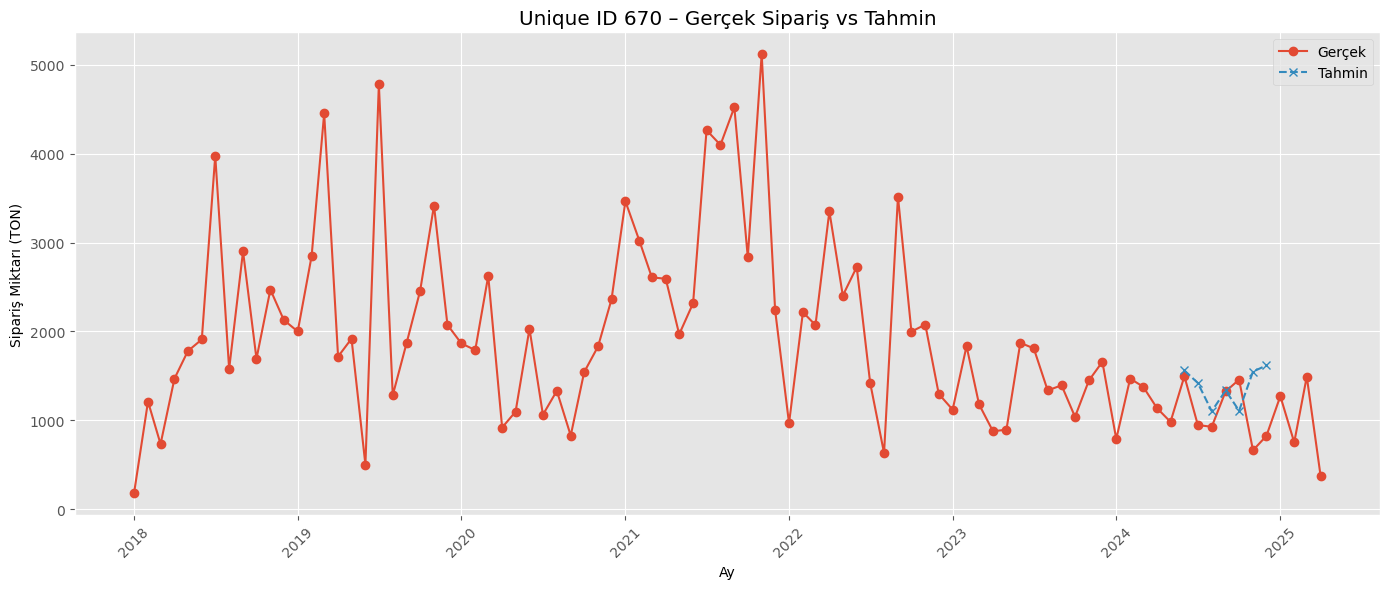

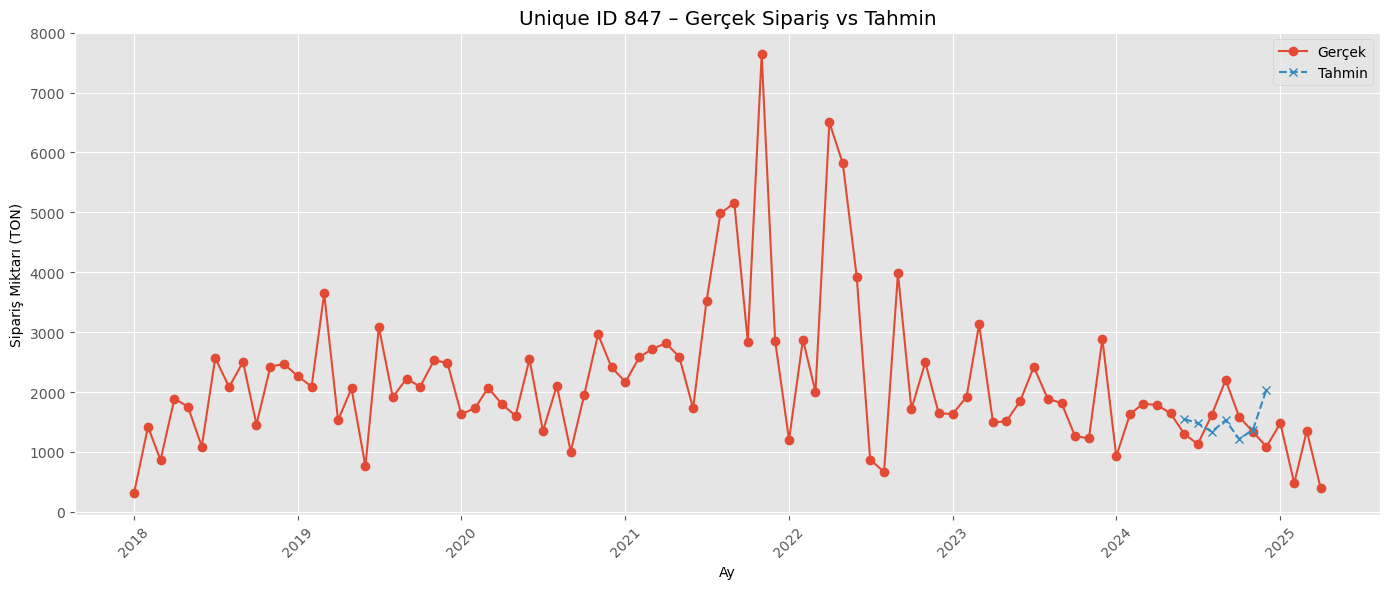

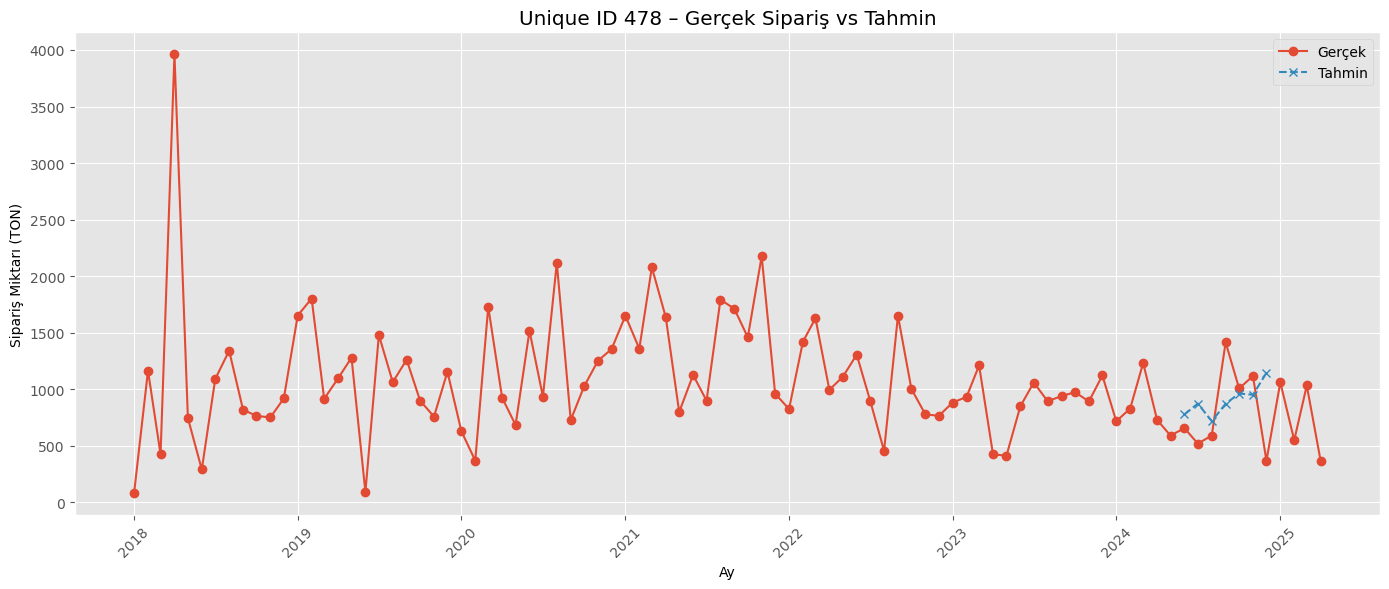

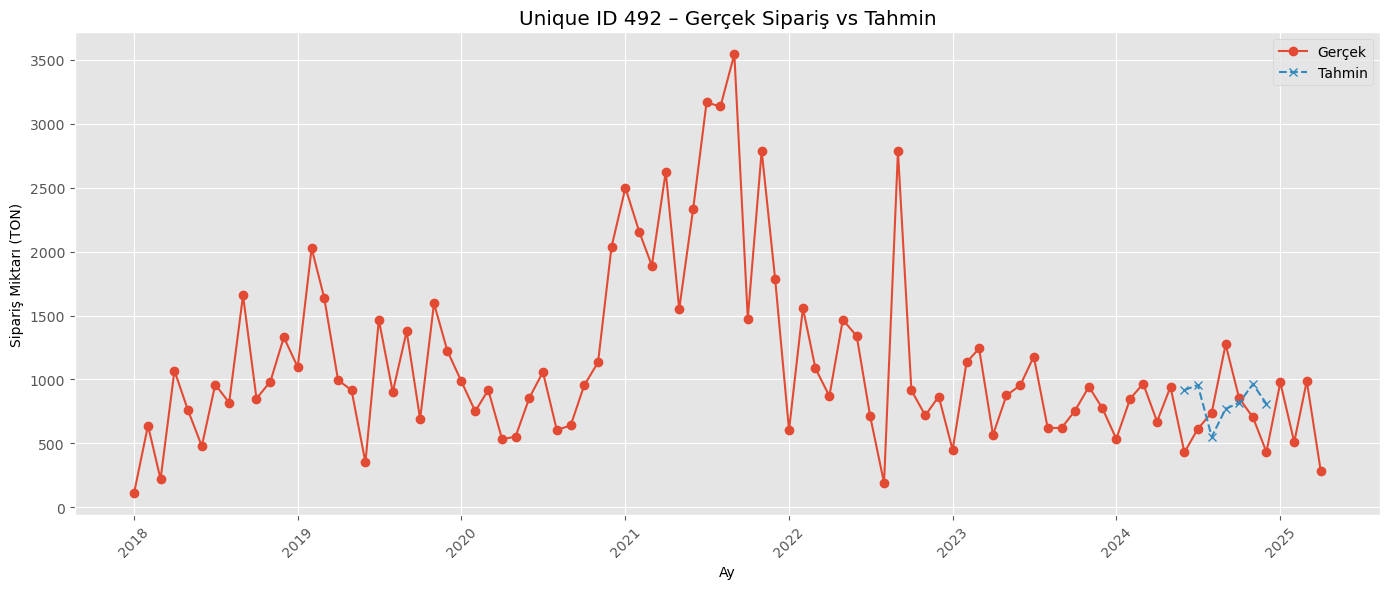

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# 🎯 Seçmek istediğin unique_id’leri belirle
selected_ids = ['670', '847','478','492']  # ilgilendiğin ID'leri yaz

for uid in selected_ids:
    # 🔹 Gerçek veriler (old_df)
    actual_series = old_df[old_df['unique_id'] == uid][['ds', 'y']].copy()
    actual_series.set_index('ds', inplace=True)
    actual_series.rename(columns={'y': 'Actual'}, inplace=True)

    # 🔹 Tahmin veriler (mergeeee)
    forecast_series = mergeeee[mergeeee['unique_id'] == uid][['ds', 'y_hat']].copy()
    forecast_series.set_index('ds', inplace=True)
    forecast_series.rename(columns={'y_hat': 'Forecast'}, inplace=True)

    # 🔗 Ay atlamadan birleştir
    all_dates = pd.date_range(start=min(actual_series.index.min(), forecast_series.index.min()),
                              end=max(actual_series.index.max(), forecast_series.index.max()),
                              freq='MS')

    full_df = pd.DataFrame(index=all_dates)
    full_df = full_df.join(actual_series)
    full_df = full_df.join(forecast_series)

    # 📈 Grafik çizimi
    plt.figure(figsize=(14, 6))
    plt.plot(full_df.index, full_df['Actual'], label='Gerçek', marker='o')
    plt.plot(full_df.index, full_df['Forecast'], label='Tahmin', linestyle='--', marker='x')
    plt.title(f"Unique ID {uid} – Gerçek Sipariş vs Tahmin")
    plt.xlabel("Ay")
    plt.ylabel("Sipariş Miktarı (TON)")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()





In [15]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

# 🎯 Seçmek istediğin unique_id’leri belirle
selected_ids = ['670', '847','478','492']

# Sonuçları saklamak için boş DataFrame
metrics_df = pd.DataFrame(columns=['UniqueID', 'MAE', 'MAPE (%)', 'sMAPE (%)', 'wMAPE (%)', 'RMSE'])

for uid in selected_ids:
    # 🔹 İlgili unique_id'ye göre veri seç
    df_selected = mergeeee[mergeeee['unique_id'] == uid].copy()
    df_selected = df_selected.dropna(subset=['y', 'y_hat'])  # NaN varsa temizle

    y_true = df_selected['y']
    y_pred = df_selected['y_hat']

    # 📐 Hata metriklerini hesapla
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
    wmape = 100 * np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true))

    # Sonuçları ekle
    metrics_df = pd.concat([metrics_df, pd.DataFrame({
        'UniqueID': [uid],
        'MAE': [mae],
        'MAPE (%)': [mape],
        'sMAPE (%)': [smape],
        'wMAPE (%)': [wmape],
        'RMSE': [rmse]
    })], ignore_index=True)

# 📊 Sonuçları göster
print(metrics_df)



  UniqueID    MAE  MAPE (%)  sMAPE (%)  wMAPE (%)   RMSE
0      670 392.84     46.77      33.49      35.98 505.96
1      847 416.32     30.31      27.08      28.41 502.55
2      478 304.58     53.72      36.80      37.55 393.29
3      492 314.09     51.87      41.59      43.55 349.62


In [16]:
# Function to save datasets
def save_datasets(X_train_df, y_train_df, X_test_df, y_test_df, folder_path="/Users/cankocak/Desktop/Spring25/"):
    
    
    import os
    os.makedirs(folder_path, exist_ok=True)  # Ensure directory exists

    # Save DataFrames
    X_train_df.to_csv(f"{folder_path}X_train_df.csv", index=False)
    y_train_df.to_csv(f"{folder_path}y_train_df.csv", index=False)
    X_test_df.to_csv(f"{folder_path}X_test_df.csv", index=False)
    y_test_df.to_csv(f"{folder_path}y_test_df.csv", index=False)

    print(f"Data saved in '{folder_path}' before running the model.")

# Ensure Data Is Clean Before Saving
X_train_df = X_train_df.dropna().reset_index(drop=True)
y_train_df = y_train_df.dropna().reset_index(drop=True)
X_test_df = X_test_df.dropna().reset_index(drop=True)
y_test_df = y_test_df.dropna().reset_index(drop=True)

# Save Data Before Running the Model
#save_datasets(X_train_df, y_train_df, X_test_df, y_test_df)

In [17]:
# Generate forecasts
forecasts = model.predict(X_test_df, y_test_df)
print(forecasts[:1000])

    unique_id         ds  x  y_hat
0           1 2024-06-01  A  61.88
1           1 2024-07-01  A  46.03
2           1 2024-08-01  A  22.64
3           1 2024-09-01  A  80.60
4           1 2024-10-01  A  13.79
..        ...        ... ..    ...
995      1126 2024-07-01  A   0.00
996      1126 2024-08-01  A   0.00
997      1126 2024-09-01  A   0.00
998      1126 2024-10-01  A   0.00
999      1126 2024-11-01  A   0.00

[1000 rows x 4 columns]
